In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import anderson_ksamp
import mlflow
import torch
from torch import nn, optim
import torch.utils.data as data_utils
from IPython.display import clear_output
from pytorch_lightning import Trainer
from pytorch_lightning.utilities.seed import seed_everything
from pytorch_lightning.callbacks import Callback
import yaml

from genhack.dataset import StationsDataset
from genhack.models import models
from genhack.utils import *
from train import train

In [3]:
df_all = pd.read_csv('data/df_all.csv')
df_all['dates'] = pd.to_datetime(df_all['dates'])
df_all = df_all.set_index('dates').sort_index()

df_train = pd.read_csv('data/df_train.csv')
df_train['dates'] = pd.to_datetime(df_train['dates'])
df_train = df_train.set_index('dates').sort_index()

df_test = pd.read_csv('data/df_test.csv')
df_test['dates'] = pd.to_datetime(df_test['dates'])
df_test = df_test.set_index('dates').sort_index()

# Intramonth dependencies

Text(0.5, 1.0, 'Year = 2007, over all months')

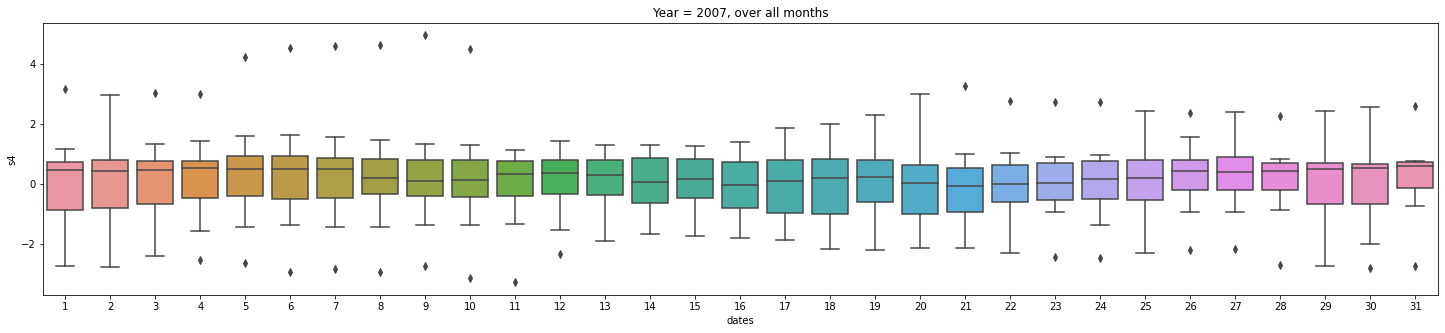

In [4]:
year = 2007
station = 's4'

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all[df_all.index.year == year]
sns.boxplot(y=df_plot[station], x=df_plot.index.day, ax=ax)
ax.set_title(f"Year = {year}, over all months")

Text(0.5, 1.0, 'Month = 8, over all years')

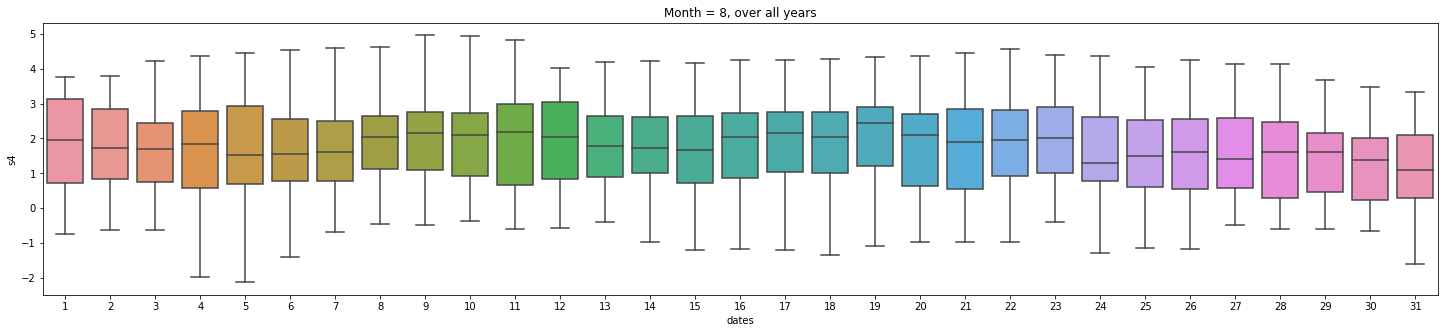

In [5]:
month = 8
station = 's4'

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all[df_all.index.month == month]
sns.boxplot(y=df_plot[station], x=df_plot.index.day, ax=ax)
ax.set_title(f"Month = {month}, over all years")

# Intrayear dependencies

Text(0.5, 1.0, 'Monthly boxplots, for all years, station s4')

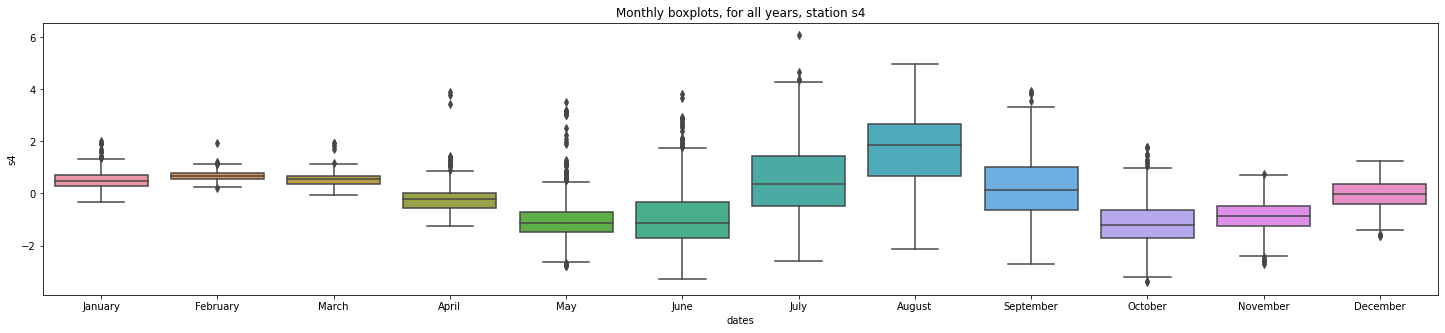

In [272]:
year = 2007
station = 's4'

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all[df_all.index.year >= 1982]
sns.boxplot(y=df_plot[station], x=df_plot.index.month_name(), ax=ax)
ax.set_title(f'Monthly boxplots, for all years, station {station}')

Text(0.5, 1.0, 'Monthly boxplots, for year 2007, station s4')

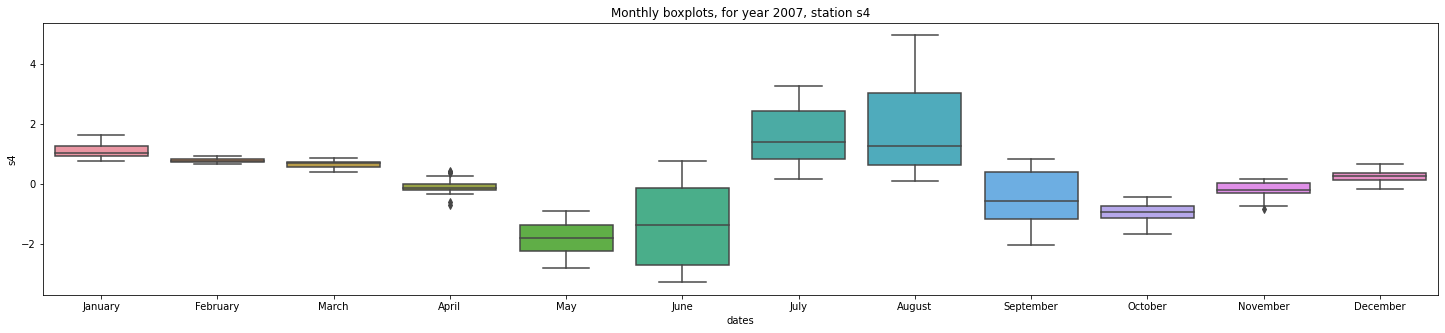

In [273]:
year = 2007
station = 's4'

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all[df_all.index.year == year]
sns.boxplot(y=df_plot[station], x=df_plot.index.month_name(), ax=ax)
ax.set_title(f'Monthly boxplots, for year {year}, station {station}')

Text(0.5, 1.0, 'Mean of s4')

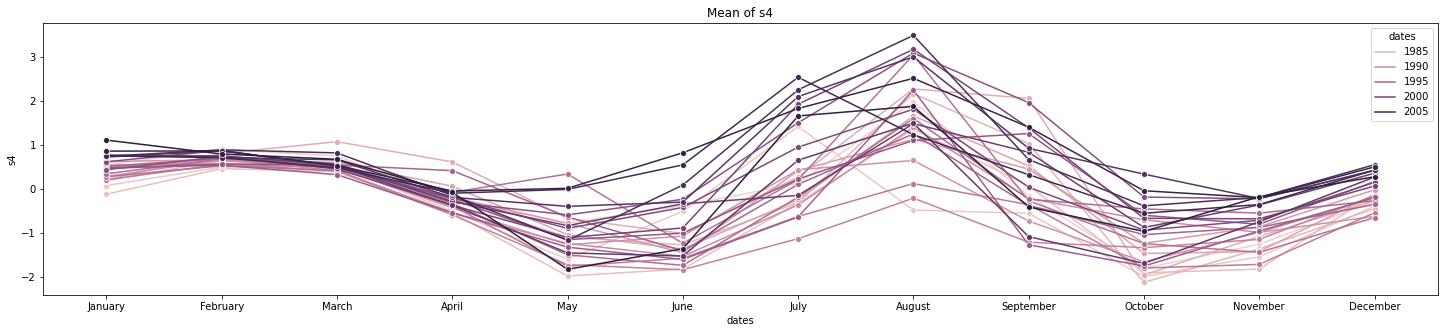

In [460]:
station = 's4'

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all.resample('M').mean().iloc[4:]
sns.lineplot(y=df_plot[station], x=df_plot.index.month_name(), hue=df_plot.index.year, ax=ax, marker='o')
ax.set_title(f'Mean of {station}')

Text(0.5, 1.0, 'STD of s5, over all years')

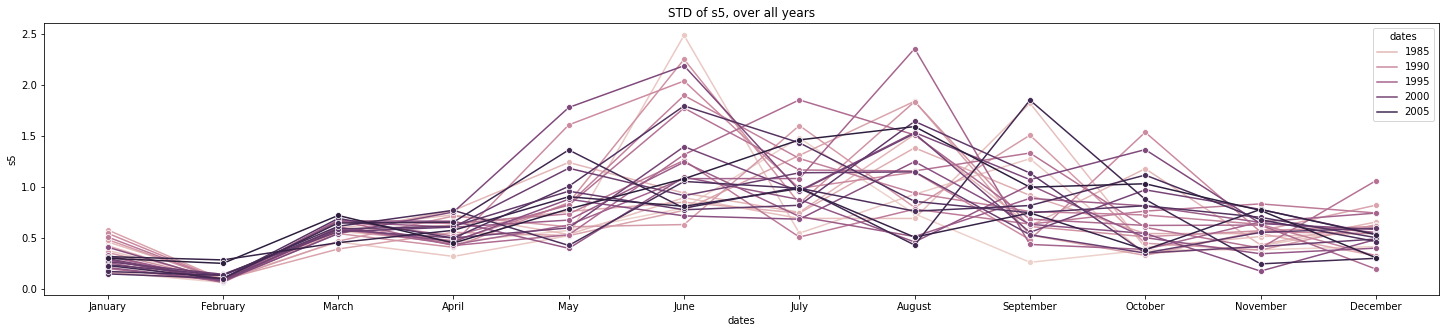

In [461]:
station = 's5'

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all.resample('M').std().iloc[4:]
sns.lineplot(y=df_plot[station], x=df_plot.index.month_name(), hue=df_plot.index.year, ax=ax, marker='o')
ax.set_title(f'STD of {station}')

# Dependencies over years

Text(0.5, 1.0, 'Yearly mean over all stations')

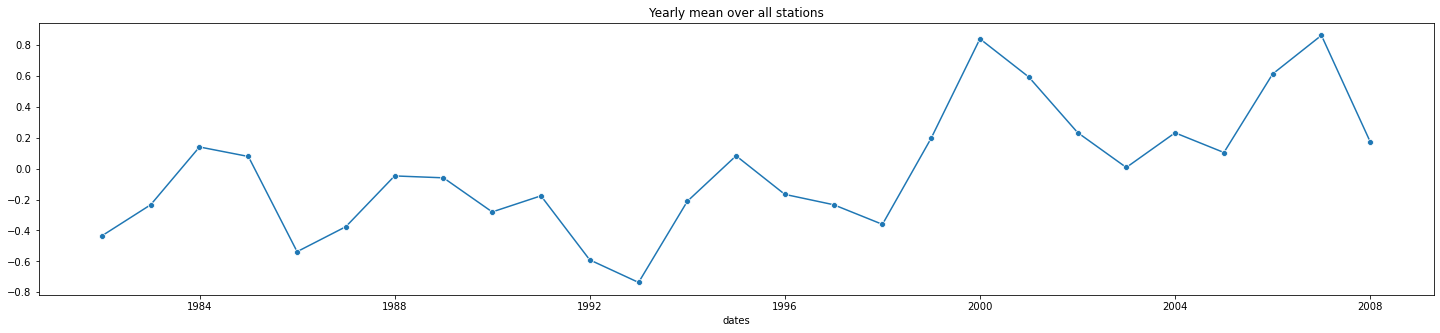

In [39]:
fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all.resample('Y').mean().mean(axis=1)
sns.lineplot(data=df_plot, ax=ax, marker='o')
ax.set_title('Yearly mean over all stations')

Text(0.5, 1.0, 'Yearly mean, station = s2')

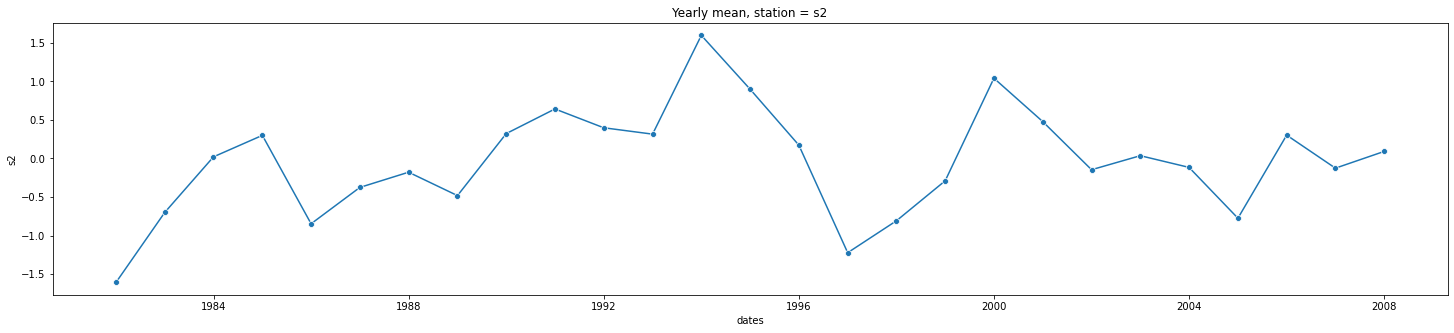

In [58]:
station = 's2'

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all.resample('Y').mean()[station]
sns.lineplot(data=df_plot, ax=ax, marker='o')
ax.set_title(f'Yearly mean, station = {station}')

Text(0.5, 1.0, 'Monthly mean, station = s1')

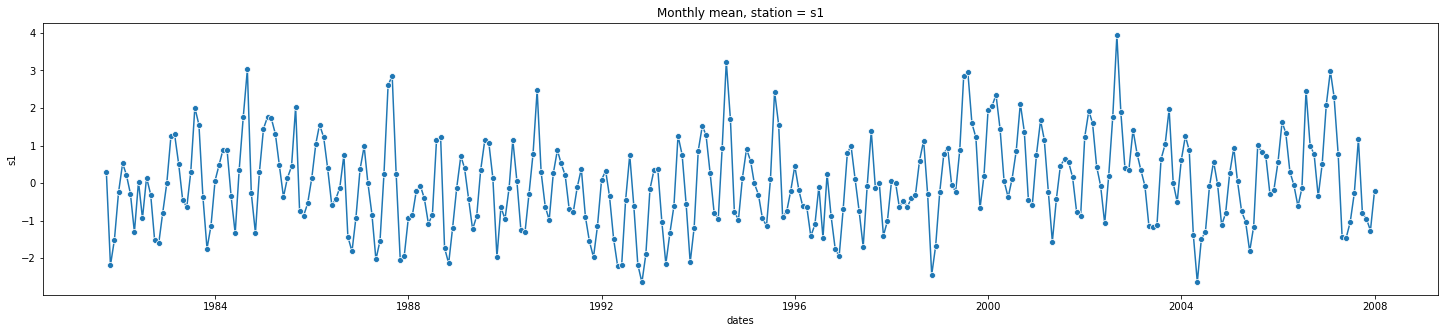

In [36]:
station = 's1'

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all.resample('M').mean()[station]
sns.lineplot(data=df_plot, ax=ax, marker='o')
ax.set_title(f'Monthly mean, station = {station}')

Text(0.5, 1.0, 'Yearly mean')

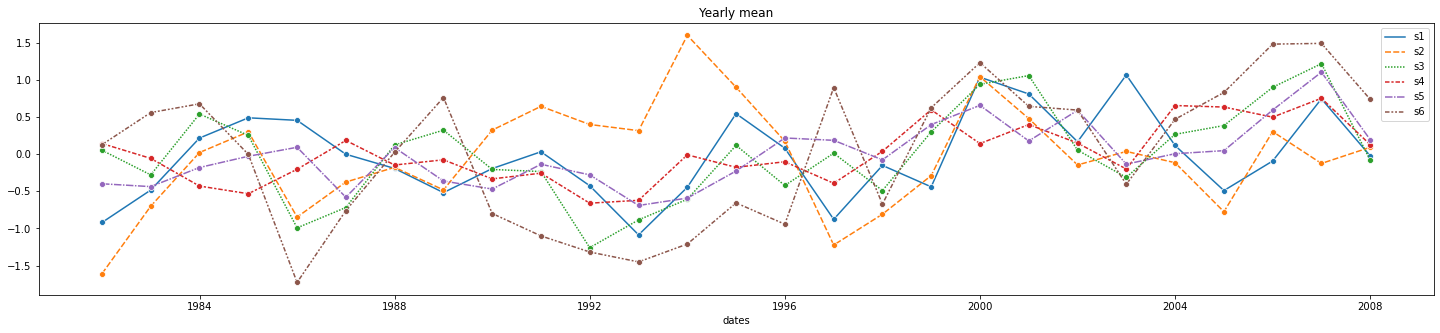

In [463]:
fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all.resample('Y').mean()
sns.lineplot(data=df_plot, ax=ax, marker='o')
ax.set_title('Yearly mean')

Text(0.5, 1.0, 'Monthly mean')

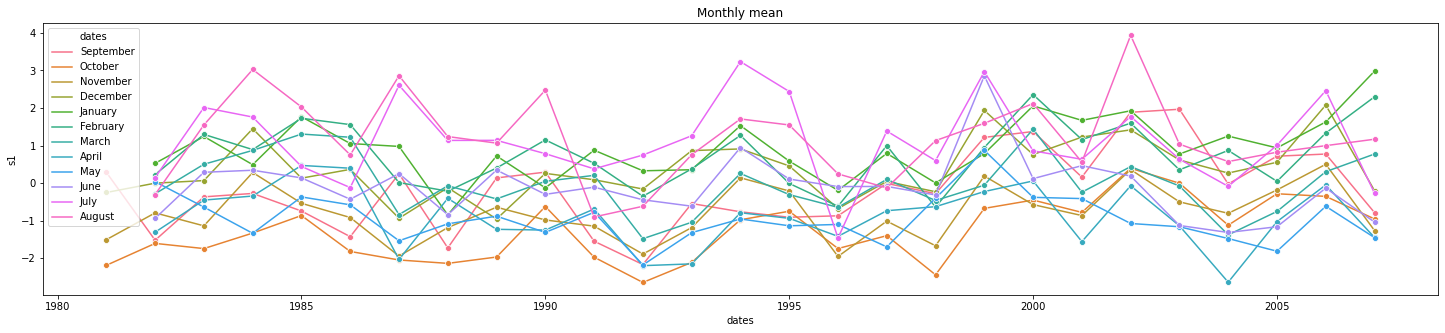

In [464]:
station = 's1'

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all.resample('M').mean()
sns.lineplot(data=df_plot, x=df_plot.index.year, y=station, hue=df_plot.index.month_name(), ax=ax, marker='o')
ax.set_title('Monthly mean')

Text(0.5, 1.0, 'Monthly mean')

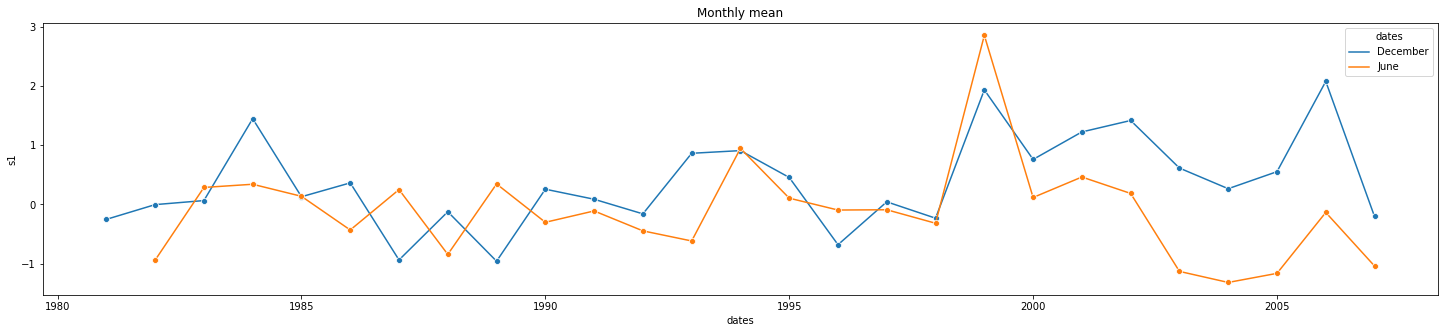

In [10]:
station = 's1'
months = 6, 12

fig, ax = plt.subplots(figsize=(25, 5))
ax.set_title(station)
df_plot = df_all.resample('M').mean()
df_plot = df_plot[df_plot.index.month.isin(months)]
sns.lineplot(data=df_plot, x=df_plot.index.year, y=station, hue=df_plot.index.month_name(), ax=ax, marker='o')
ax.set_title('Monthly mean')

Text(0.5, 1.0, 'Monthly averages for station s3, month 4')

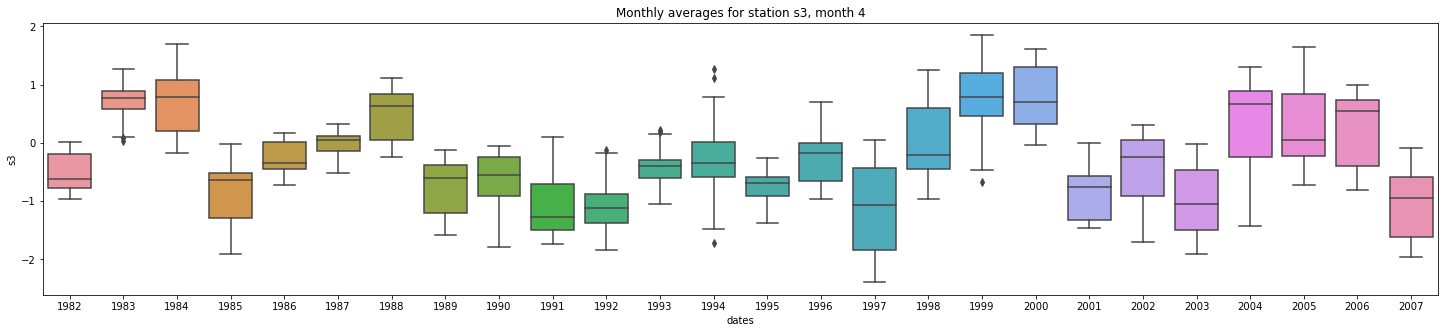

In [12]:
station = 's3'
month = 4

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all[df_all.index.month == month]
sns.boxplot(y=df_plot[station], x=df_plot.index.year, ax=ax)
ax.set_title(f'Monthly averages for station {station}, month {month}')

# Histograms

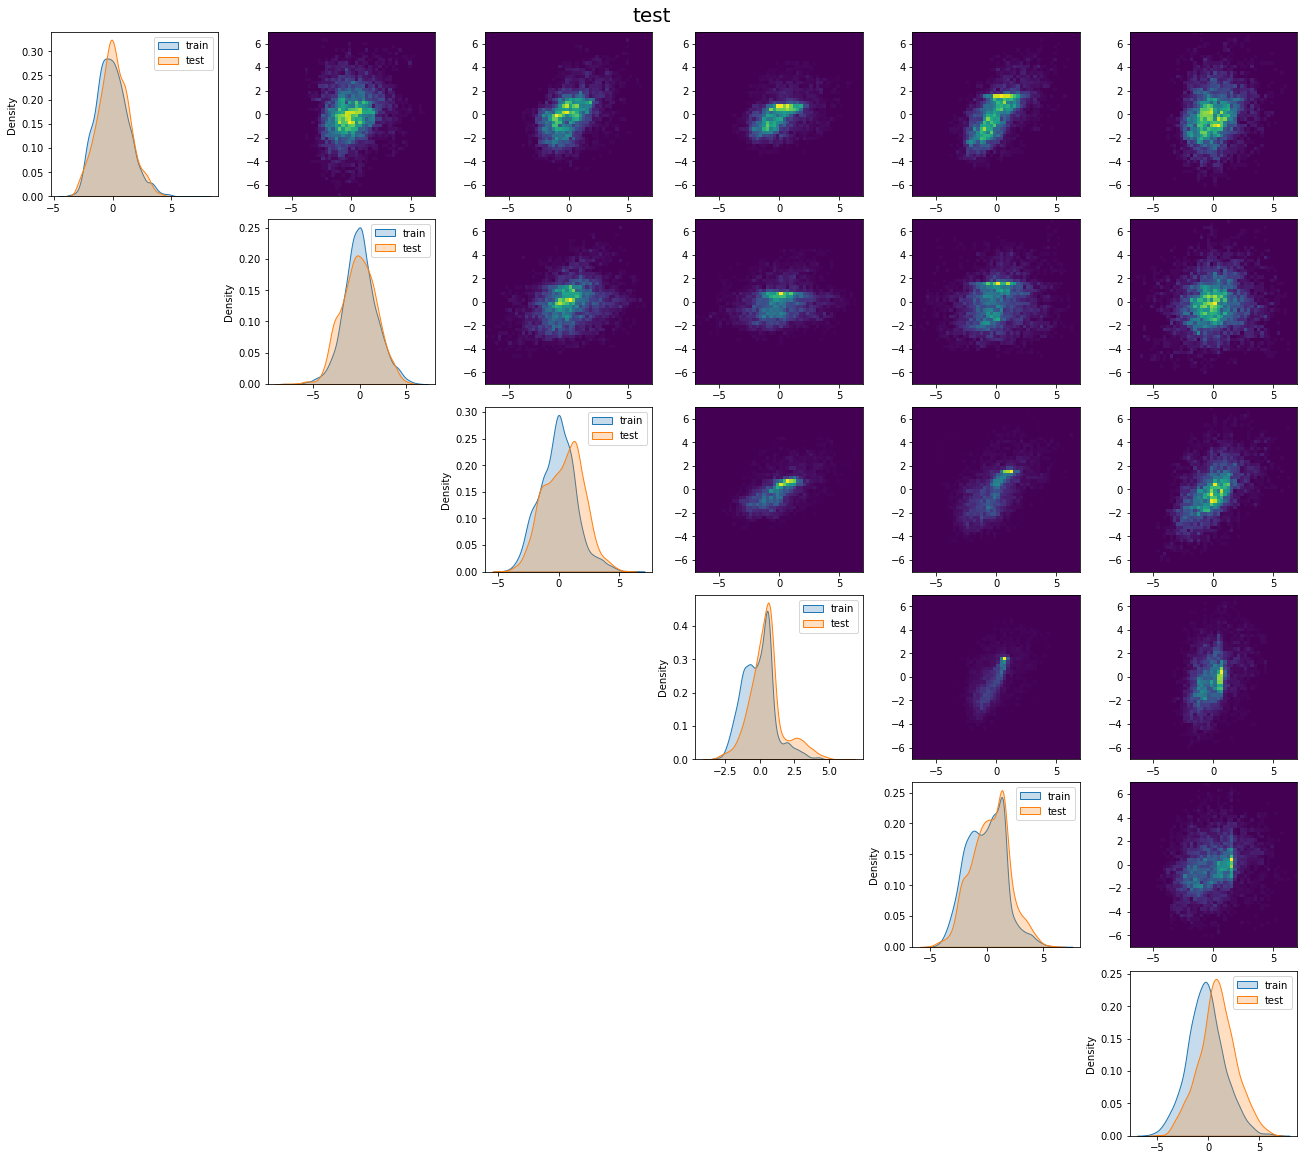

In [467]:
# all months

fig, ax = plt.subplots(nrows=6, ncols=6, figsize=(18, 16), constrained_layout=True)
fig.suptitle('test', fontsize=20)

for i in range(6):
    for j in range(6):
        if i < j:
            ax[i][j].hist2d(df_train[f's{i+1}'], df_train[f's{j+1}'], bins=50, range=[[-7, 7], [-7, 7]])
        if i > j:
            fig.delaxes(ax[i][j])
    sns.kdeplot(data=df_train.to_numpy()[:, i], ax=ax[i][i], fill=True, label='train')
    sns.kdeplot(data=df_test.to_numpy()[:, i], ax=ax[i][i], fill=True, label='test')
    ax[i][i].legend()


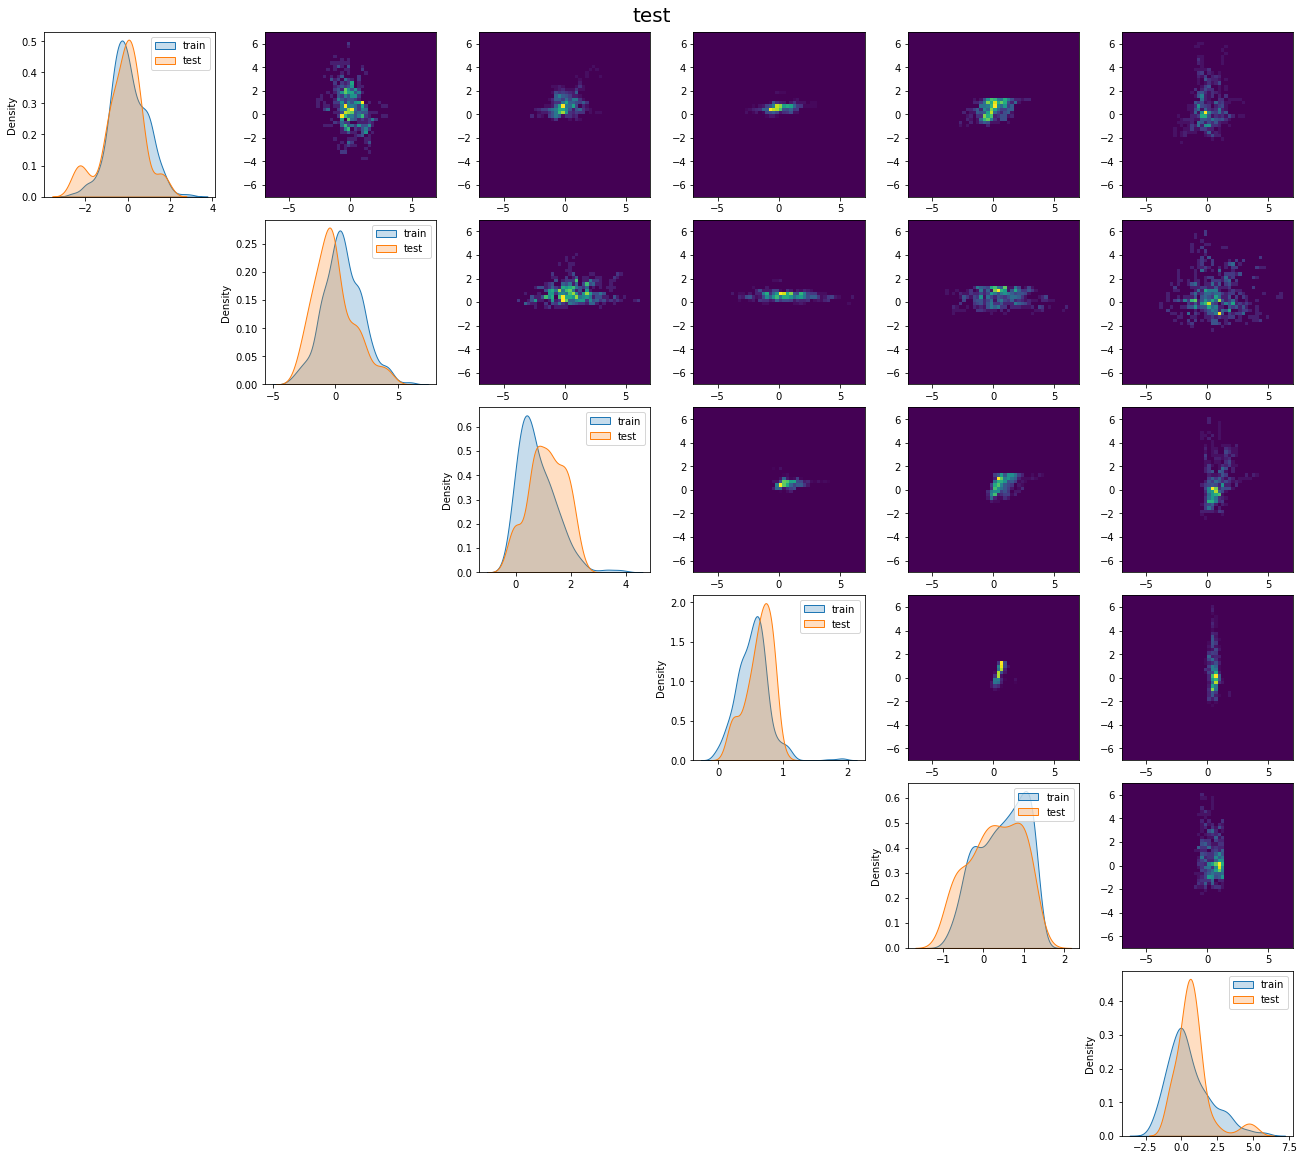

In [468]:
# specific month

MONTH = 3

fig, ax = plt.subplots(nrows=6, ncols=6, figsize=(18, 16), constrained_layout=True)
fig.suptitle('test', fontsize=20)

for i in range(6):
    for j in range(6):
        if i < j:
            ax[i][j].hist2d(df_train[df_train.index.month == MONTH][f's{i+1}'], df_train[df_train.index.month == MONTH][f's{j+1}'], bins=50, range=[[-7, 7], [-7, 7]])
        if i > j:
            fig.delaxes(ax[i][j])
    sns.kdeplot(data=df_train[df_train.index.month == MONTH].to_numpy()[:, i], ax=ax[i][i], fill=True, label='train')
    sns.kdeplot(data=df_test[df_test.index.month == MONTH].to_numpy()[:, i], ax=ax[i][i], fill=True, label='test')
    ax[i][i].legend()
    

# TSNE

In [469]:
from sklearn.manifold import TSNE

<AxesSubplot:xlabel='comp-1', ylabel='comp-2'>

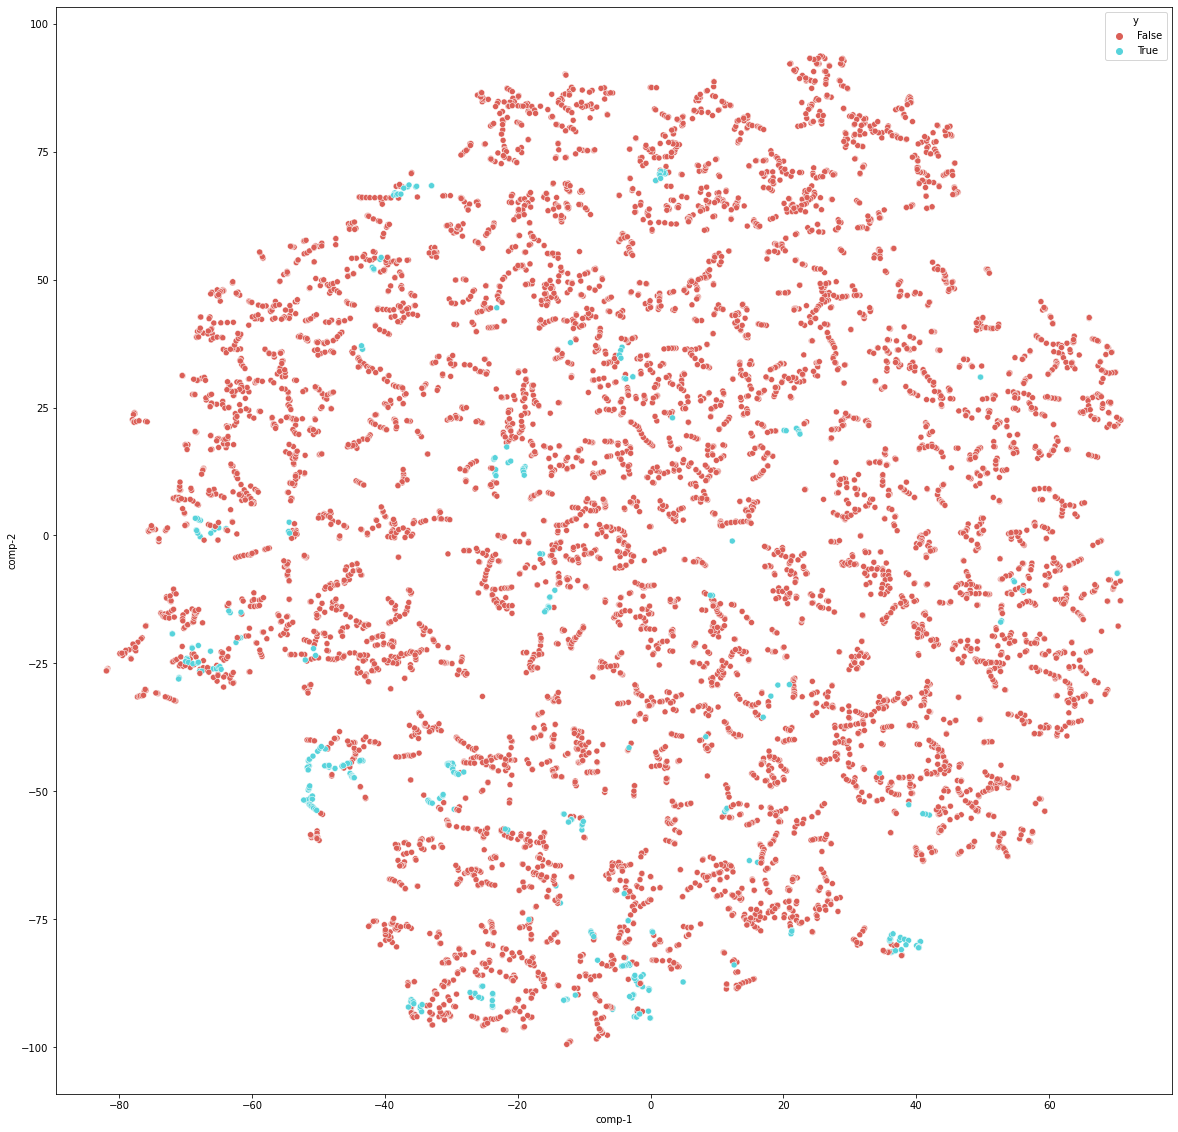

In [470]:
# tsne = TSNE(n_components=2, verbose=1, random_state=1337)
# z = tsne.fit_transform(df)
df_tsne = pd.DataFrame()
df_tsne["y"] = df.index.year
df_tsne["comp-1"] = z[:,0]
df_tsne["comp-2"] = z[:,1]

fig, ax = plt.subplots(figsize=(20, 20))
# sns.scatterplot(x="comp-1", y="comp-2", hue='y', palette=sns.color_palette("hls", 12), data=df_tsne, ax=ax)
sns.scatterplot(x="comp-1", y="comp-2", hue=df_tsne['y'] == 1999, palette=sns.color_palette("hls", 2), data=df_tsne, ax=ax)